In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pyarrow
import seaborn as sns
from pathlib import Path

# Project directory
project_path = Path(r"C:\Users\alex-\OneDrive\Documents\GitHub\CU-Capstone-Project")

# Processed data folder
data_path = project_path / "data" / "processed"

# Load datasets
metmasts = pd.read_parquet(data_path / "metmasts_data.parquet")
scada = pd.read_parquet(data_path / "scada_data.parquet")

# Display dataset information
for name, df in {"Met Masts": metmasts, "SCADA": scada}.items():
    print(f"\n{'='*50}")
    print(f"DATASET: {name}")
    print(f"Rows: {df.shape[0]:,}")
    print(f"Columns: {df.shape[1]:,}")

    print("\nVARIABLES:")
    for col in df.columns:
        print(col)

# Preview datasets
display(metmasts.head())
display(scada.head())


DATASET: Met Masts
Rows: 39,306
Columns: 14

VARIABLES:
utc
mm_wind_speed_1
mm_wind_speed_2
mm_wind_speed_3
mm_wind_speed_hh
mm_wind_direction_1
mm_wind_direction_2
mm_wind_direction_3
mm_wind_direction_hh
mm_pressure_bar_1
mm_pressure_bar_2
mm_rel_humidity_1
mm_rel_humidity_2
mm_temp_amb

DATASET: SCADA
Rows: 1,833,846
Columns: 19

VARIABLES:
utc
turbine
air_density
KPI_temp_ambient_merged
KPI_temp_ambient
KPI_theoretical_power
KPI_real_power_ac
real_power_ac
KPI_wind_speed
wind_speed
wind_direction
wind_direction_relative
nacelle_pos
blade_1_pos
blade_2_pos
blade_3_pos
blade_1_setpos
blade_2_setpos
blade_3_setpos


,utc,mm_wind_speed_1,mm_wind_speed_2,mm_wind_speed_3,mm_wind_speed_hh,mm_wind_direction_1,mm_wind_direction_2,mm_wind_direction_3,mm_wind_direction_hh,mm_pressure_bar_1,mm_pressure_bar_2,mm_rel_humidity_1,mm_rel_humidity_2,mm_temp_amb
0,2026-01-01 08:00:00,NaN,6.788382,5.399412,0.700615,71.916912,54.936030,67.719853,47.655736,NaN,875.645740,11.372340,4.810286,NaN
1,2026-01-01 08:10:00,NaN,6.259118,5.094412,0.697460,67.399852,51.146323,64.681471,43.452206,NaN,875.537235,11.323674,4.573111,NaN
2,2026-01-01 08:20:00,NaN,6.533529,5.542794,0.703226,72.914559,57.126323,70.034118,51.133089,NaN,875.370256,11.276522,4.534419,NaN
3,2026-01-01 08:30:00,NaN,6.125970,5.133824,0.711940,86.105735,65.834329,84.872500,58.976618,NaN,875.402339,11.249778,4.145185,NaN
4,2026-01-01 08:40:00,NaN,5.931143,5.168986,0.691642,90.357286,68.262572,87.822753,61.110143,NaN,875.489709,11.124737,4.001458,NaN


,utc,turbine,air_density,KPI_temp_ambient_merged,KPI_temp_ambient,KPI_theoretical_power,KPI_real_power_ac,real_power_ac,KPI_wind_speed,wind_speed,wind_direction,wind_direction_relative,nacelle_pos,blade_1_pos,blade_2_pos,blade_3_pos,blade_1_setpos,blade_2_setpos,blade_3_setpos
0,2026-01-01 08:00:00,WTG150,1.092081,8.299405,8.299405,746.68463,672.60510,670.286714,6.906036,6.907681,115.629870,-1.392857,118.785714,NaN,-1.056245,-0.643520,2.307242,-0.892182,-0.471435
1,2026-01-01 08:00:00,WTG151,1.087094,9.592089,9.592089,406.01855,485.57794,485.492347,5.730449,5.717620,116.709677,6.439716,113.500000,0.614472,-0.925170,1.124203,0.856155,-0.676644,1.384543
2,2026-01-01 08:00:00,WTG152,1.090355,8.745550,8.745550,440.09213,497.79605,496.384967,5.862610,5.836812,252.291139,-5.909091,259.600000,-0.481281,0.200810,0.278822,NaN,NaN,NaN
3,2026-01-01 08:00:00,WTG153,1.044950,21.009600,21.009600,445.82935,423.57132,422.188638,5.969328,5.951737,283.955414,-6.215278,291.230769,-0.059970,0.342474,-0.278986,-0.027131,0.376825,-0.244748
4,2026-01-01 08:00:00,WTG154,1.088453,9.238713,9.238713,208.84138,274.52768,274.276035,4.760764,4.757731,139.118343,-4.608108,140.000000,-1.428621,1.907079,1.215503,-1.376194,1.938141,1.257423


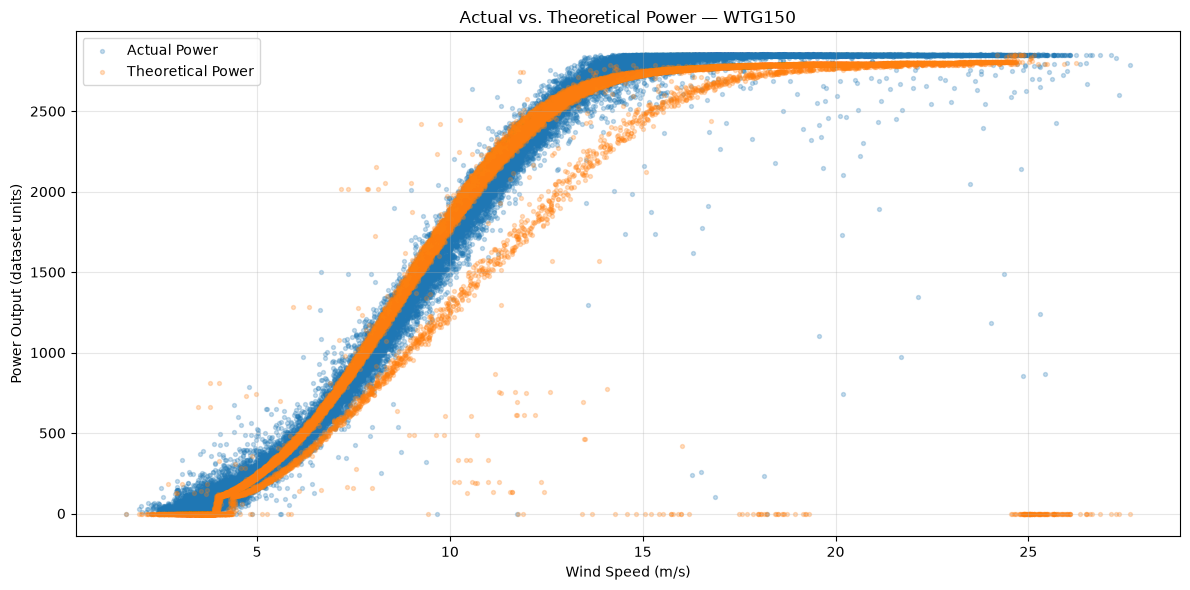

In [6]:
# Select variables for power analysis
power_data = scada[
    [
        "turbine",
        "wind_speed",
        "KPI_theoretical_power",
        "real_power_ac"
    ]
].copy()

# Remove missing measurements
power_data = power_data.dropna()

# Select one turbine
turbine_id = "WTG150"

turbine_data = power_data[
    power_data["turbine"] == turbine_id
]

# Create visualization
plt.figure(figsize=(12, 6))

plt.scatter(
    turbine_data["wind_speed"],
    turbine_data["real_power_ac"],
    alpha=0.25,
    s=8,
    label="Actual Power"
)

plt.scatter(
    turbine_data["wind_speed"],
    turbine_data["KPI_theoretical_power"],
    alpha=0.25,
    s=8,
    label="Theoretical Power"
)

plt.xlabel("Wind Speed (m/s)")
plt.ylabel("Power Output (dataset units)")
plt.title(f"Actual vs. Theoretical Power — {turbine_id}")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [7]:
print("Number of turbines:", scada["turbine"].nunique())

print("\nTurbines:")
print(scada["turbine"].unique())

print("\nDate range:")
print("Start:", scada["utc"].min())
print("End:", scada["utc"].max())

print("\nSCADA variables:")
print(scada.columns.tolist())

Number of turbines: 47

Turbines:
<ArrowStringArray>
['WTG150', 'WTG151', 'WTG152', 'WTG153', 'WTG154', 'WTG155', 'WTG156',
 'WTG157', 'WTG158', 'WTG159', 'WTG161', 'WTG162', 'WTG163', 'WTG164',
 'WTG165', 'WTG166', 'WTG167', 'WTG168', 'WTG169', 'WTG170', 'WTG171',
 'WTG172', 'WTG173', 'WTG174', 'WTG175', 'WTG176', 'WTG177', 'WTG178',
 'WTG179', 'WTG180', 'WTG181', 'WTG182', 'WTG183', 'WTG184', 'WTG185',
 'WTG186', 'WTG187', 'WTG188', 'WTG189', 'WTG190', 'WTG191', 'WTG192',
 'WTG193', 'WTG194', 'WTG195', 'WTG196', 'WTG197']
Length: 47, dtype: str

Date range:
Start: 2026-01-01 08:00:00
End: 2026-09-29 06:50:00

SCADA variables:
['utc', 'turbine', 'air_density', 'KPI_temp_ambient_merged', 'KPI_temp_ambient', 'KPI_theoretical_power', 'KPI_real_power_ac', 'real_power_ac', 'KPI_wind_speed', 'wind_speed', 'wind_direction', 'wind_direction_relative', 'nacelle_pos', 'blade_1_pos', 'blade_2_pos', 'blade_3_pos', 'blade_1_setpos', 'blade_2_setpos', 'blade_3_setpos']


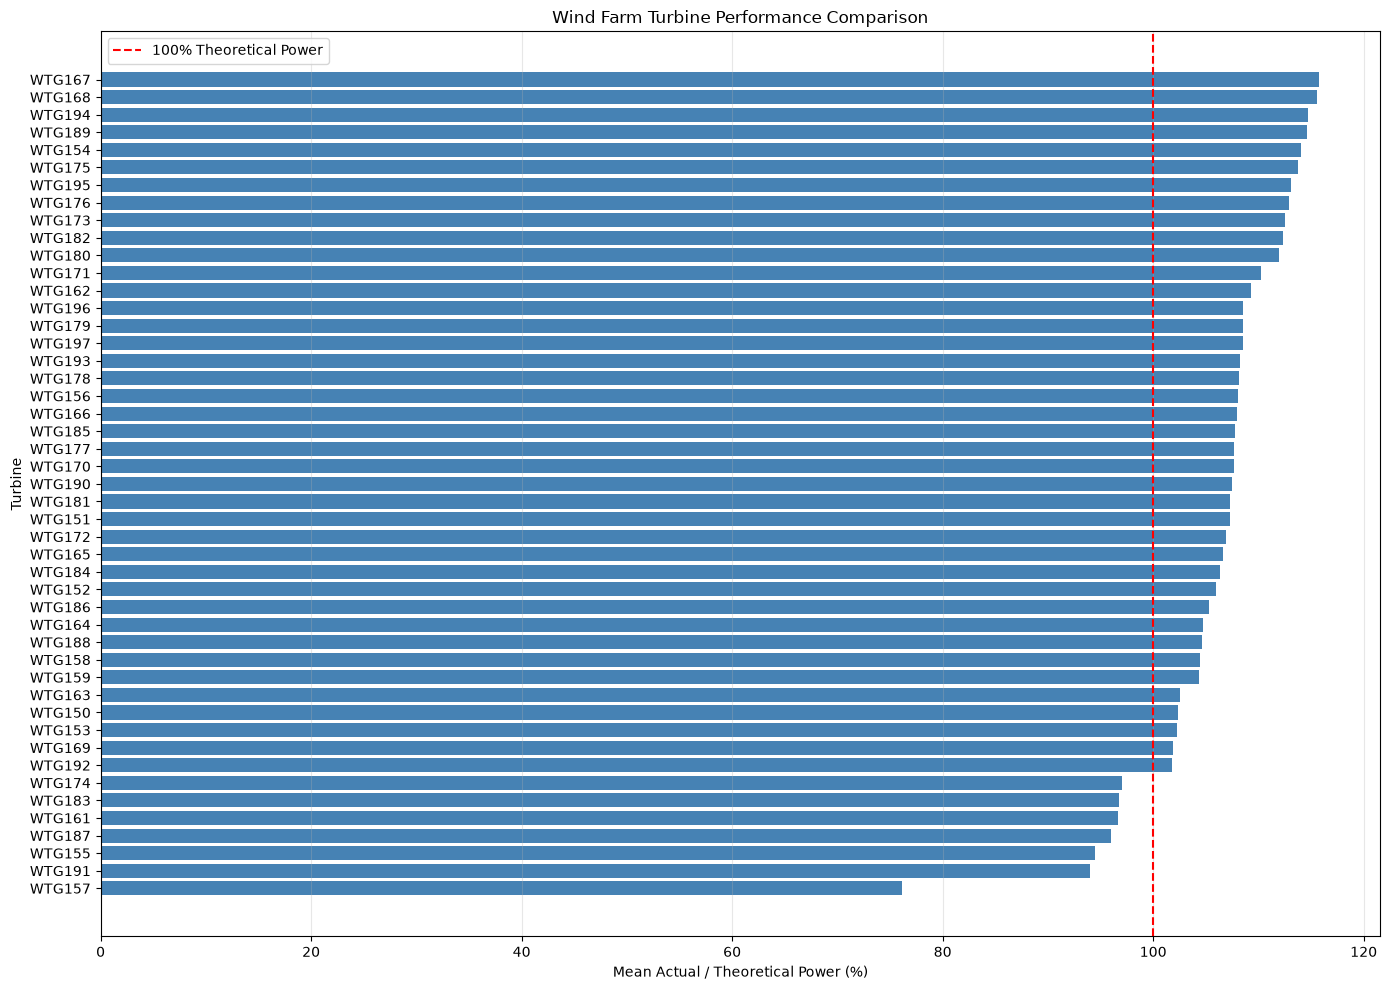

In [8]:
# Select relevant columns
performance = scada[
    ["turbine", "KPI_theoretical_power", "real_power_ac"]
].copy()

# Remove missing values
performance = performance.dropna()

# Keep observations with meaningful positive theoretical power
performance = performance[
    performance["KPI_theoretical_power"] > 100
].copy()

# Calculate power performance percentage
performance["performance_pct"] = (
    performance["real_power_ac"] /
    performance["KPI_theoretical_power"]
) * 100

# Calculate average performance for each turbine
turbine_performance = (
    performance.groupby("turbine")["performance_pct"]
    .mean()
    .sort_values()
)

# Create chart
plt.figure(figsize=(14, 10))

plt.barh(
    turbine_performance.index,
    turbine_performance.values,
    color="steelblue"
)

plt.axvline(
    100,
    color="red",
    linestyle="--",
    label="100% Theoretical Power"
)

plt.xlabel("Mean Actual / Theoretical Power (%)")
plt.ylabel("Turbine")
plt.title("Wind Farm Turbine Performance Comparison")
plt.legend()
plt.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.show()

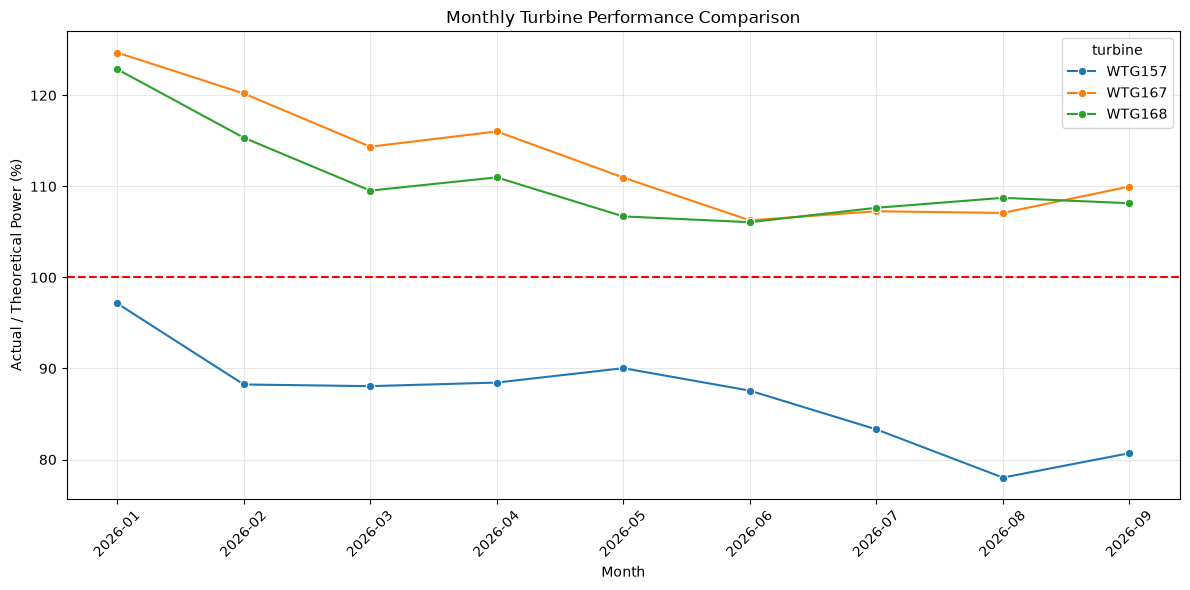

In [9]:
# Select turbines for comparison
selected_turbines = ["WTG157", "WTG167", "WTG168"]

# Create working dataframe
monthly_data = scada[
    ["utc", "turbine", "real_power_ac", "KPI_theoretical_power"]
].copy()

# Convert time column
monthly_data["utc"] = pd.to_datetime(monthly_data["utc"])

# Select turbines and remove missing values
monthly_data = monthly_data[
    monthly_data["turbine"].isin(selected_turbines)
].dropna()

# Keep positive theoretical power values
monthly_data = monthly_data[
    monthly_data["KPI_theoretical_power"] > 100
]

# Create monthly period
monthly_data["month"] = monthly_data["utc"].dt.to_period("M")

# Sum observed and theoretical power readings by month
monthly_summary = (
    monthly_data.groupby(["month", "turbine"])[
        ["real_power_ac", "KPI_theoretical_power"]
    ]
    .sum()
    .reset_index()
)

# Calculate monthly performance
monthly_summary["performance_pct"] = (
    monthly_summary["real_power_ac"] /
    monthly_summary["KPI_theoretical_power"]
) * 100

# Convert month for plotting
monthly_summary["month"] = monthly_summary["month"].astype(str)

# Plot
plt.figure(figsize=(12, 6))

sns.lineplot(
    data=monthly_summary,
    x="month",
    y="performance_pct",
    hue="turbine",
    marker="o"
)

plt.axhline(100, color="red", linestyle="--",
            label="100% Theoretical Power")

plt.title("Monthly Turbine Performance Comparison")
plt.xlabel("Month")
plt.ylabel("Actual / Theoretical Power (%)")
plt.xticks(rotation=45)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

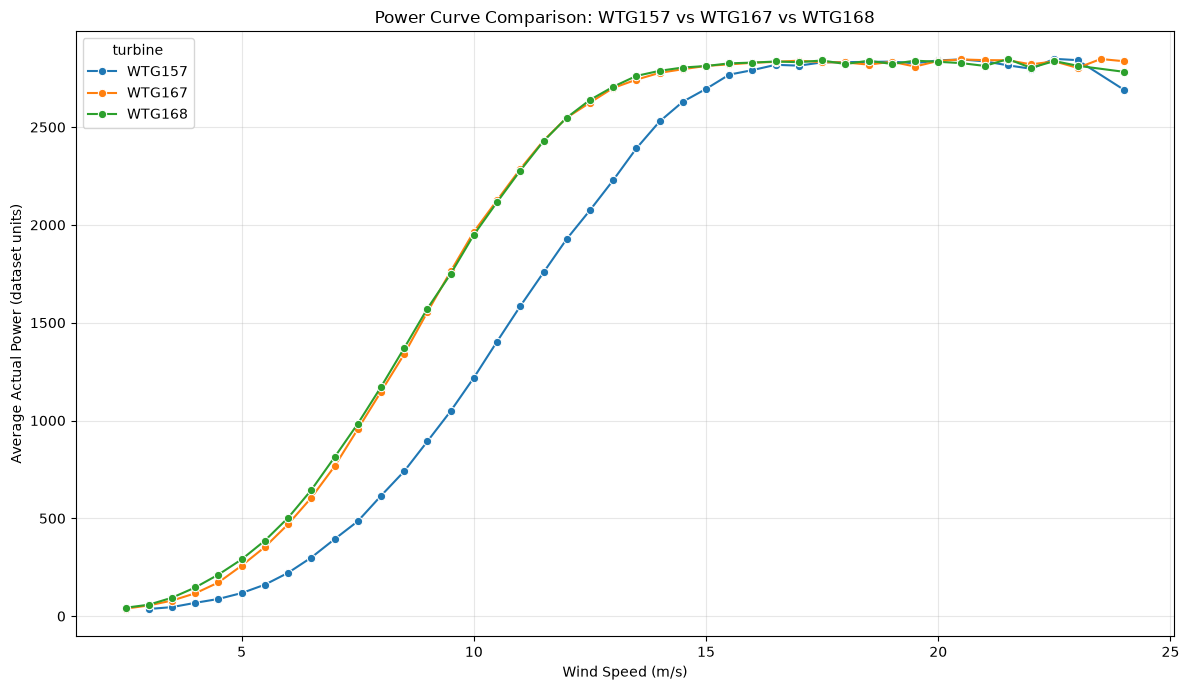

In [10]:
# Compare turbine power curves
selected = ["WTG157", "WTG167", "WTG168"]

power_compare = scada[
    ["turbine", "wind_speed", "real_power_ac"]
].copy()

power_compare = power_compare[
    power_compare["turbine"].isin(selected)
].dropna()

# Keep realistic wind speeds
power_compare = power_compare[
    power_compare["wind_speed"].between(0, 30)
].copy()

# Create 0.5 m/s wind speed bins
power_compare["wind_bin"] = (
    (power_compare["wind_speed"] / 0.5).round() * 0.5
)

# Average power in each wind speed bin
power_curves = (
    power_compare
    .groupby(["turbine", "wind_bin"])["real_power_ac"]
    .agg(["mean", "count"])
    .reset_index()
)

# Only keep bins with at least 30 measurements
power_curves = power_curves[power_curves["count"] >= 30]

# Plot
plt.figure(figsize=(12, 7))

sns.lineplot(
    data=power_curves,
    x="wind_bin",
    y="mean",
    hue="turbine",
    marker="o"
)

plt.title("Power Curve Comparison: WTG157 vs WTG167 vs WTG168")
plt.xlabel("Wind Speed (m/s)")
plt.ylabel("Average Actual Power (dataset units)")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

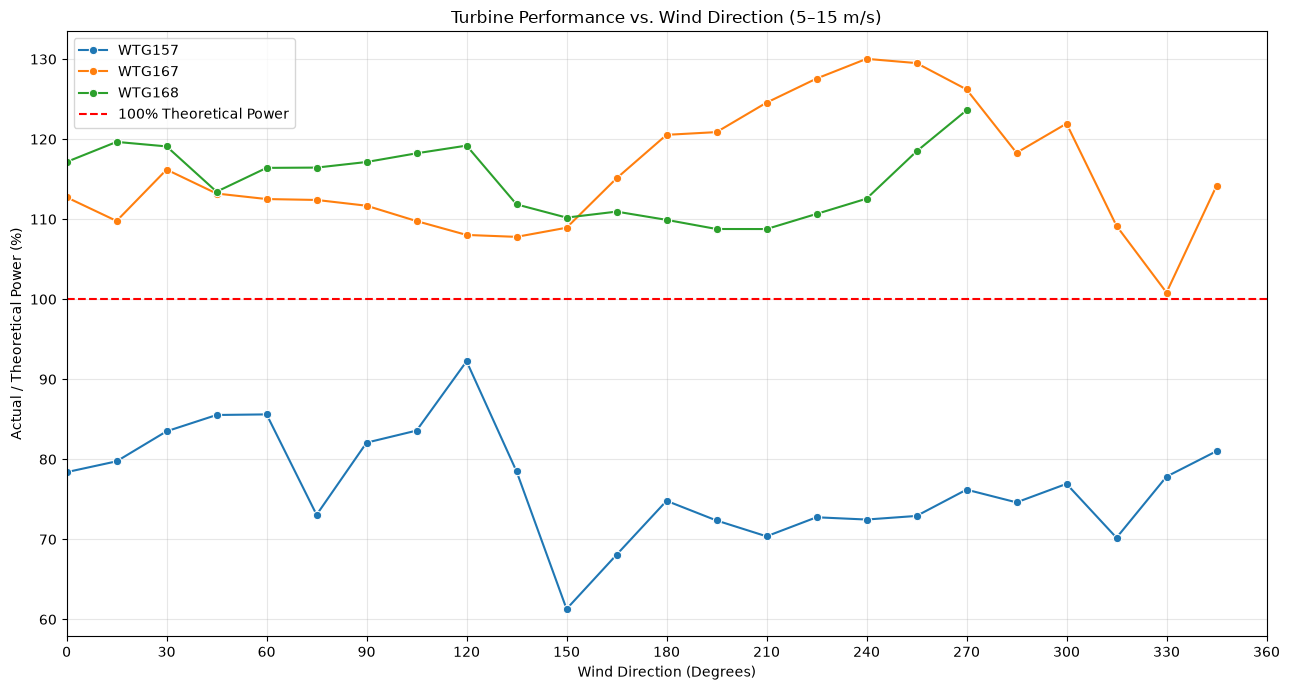

In [11]:
# ==========================================
# WIND DIRECTION VS TURBINE PERFORMANCE
# ==========================================

selected = ["WTG157", "WTG167", "WTG168"]

# Select variables
wind_data = scada[
    [
        "turbine",
        "wind_direction",
        "wind_speed",
        "real_power_ac",
        "KPI_theoretical_power"
    ]
].copy()

# Filter turbines and missing values
wind_data = wind_data[
    wind_data["turbine"].isin(selected)
].dropna()

# Filter operating wind speeds and theoretical power
wind_data = wind_data[
    wind_data["wind_speed"].between(5, 15) &
    (wind_data["KPI_theoretical_power"] > 100)
].copy()

# Group wind directions into 15-degree bins
wind_data["direction_bin"] = (
    np.floor((wind_data["wind_direction"] % 360) / 15) * 15
).astype(int)

# Calculate performance by direction
direction_summary = (
    wind_data.groupby(["turbine", "direction_bin"])
    .agg(
        actual_power=("real_power_ac", "sum"),
        theoretical_power=("KPI_theoretical_power", "sum"),
        count=("real_power_ac", "count")
    )
    .reset_index()
)

# Calculate performance percentage
direction_summary["performance_pct"] = (
    direction_summary["actual_power"] /
    direction_summary["theoretical_power"]
) * 100

# Require at least 30 observations per bin
direction_summary = direction_summary[
    direction_summary["count"] >= 30
]

# Plot
plt.figure(figsize=(13, 7))

sns.lineplot(
    data=direction_summary,
    x="direction_bin",
    y="performance_pct",
    hue="turbine",
    marker="o"
)

plt.axhline(
    100,
    color="red",
    linestyle="--",
    label="100% Theoretical Power"
)

plt.title("Turbine Performance vs. Wind Direction (5–15 m/s)")
plt.xlabel("Wind Direction (Degrees)")
plt.ylabel("Actual / Theoretical Power (%)")
plt.xticks(np.arange(0, 361, 30))
plt.xlim(0, 360)
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

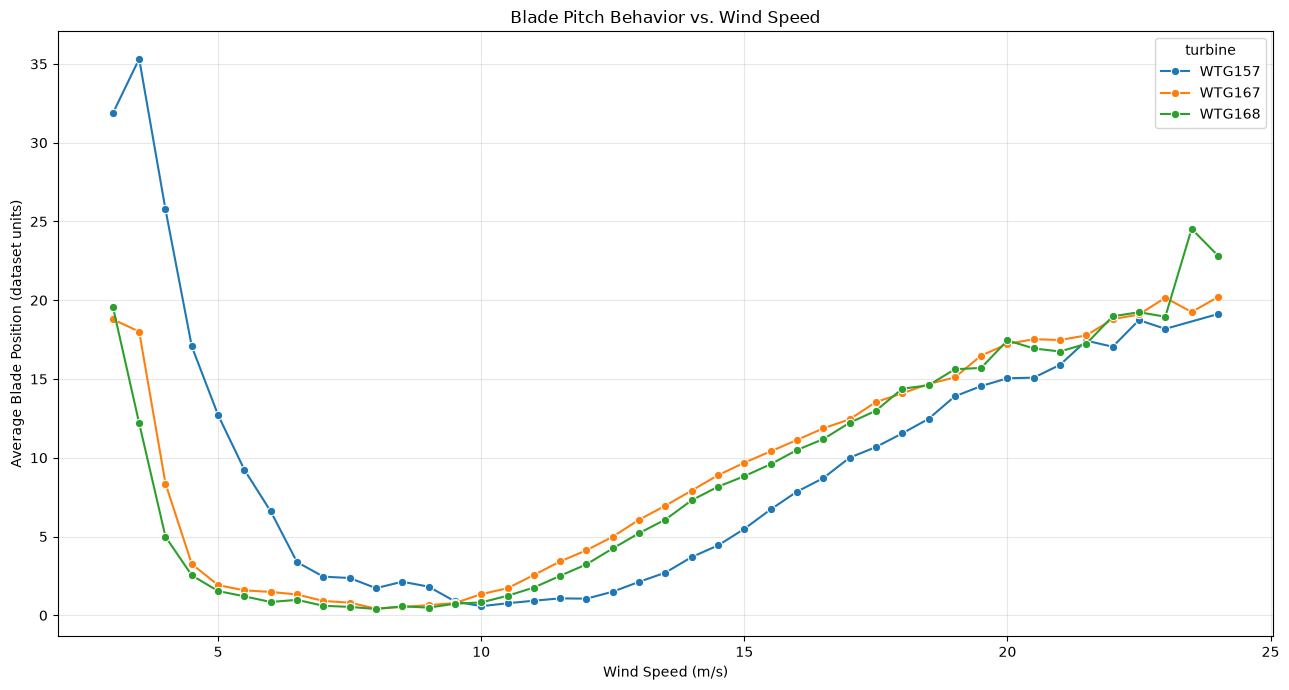

In [12]:
# ==========================================
# BLADE PITCH VS WIND SPEED
# ==========================================

selected = ["WTG157", "WTG167", "WTG168"]

# Select variables
pitch_data = scada[
    [
        "turbine",
        "wind_speed",
        "blade_1_pos",
        "blade_2_pos",
        "blade_3_pos",
        "blade_1_setpos",
        "blade_2_setpos",
        "blade_3_setpos"
    ]
].copy()

# Filter selected turbines
pitch_data = pitch_data[
    pitch_data["turbine"].isin(selected)
].copy()

# Calculate average actual blade pitch
pitch_data["avg_blade_pitch"] = pitch_data[
    ["blade_1_pos", "blade_2_pos", "blade_3_pos"]
].mean(axis=1)

# Calculate average commanded blade pitch
pitch_data["avg_setpoint"] = pitch_data[
    ["blade_1_setpos", "blade_2_setpos", "blade_3_setpos"]
].mean(axis=1)

# Remove missing measurements
pitch_data = pitch_data.dropna(
    subset=["wind_speed", "avg_blade_pitch", "avg_setpoint"]
)

# Focus on operating wind speeds
pitch_data = pitch_data[
    pitch_data["wind_speed"].between(3, 25)
].copy()

# Create wind speed bins
pitch_data["wind_bin"] = (
    (pitch_data["wind_speed"] / 0.5).round() * 0.5
)

# Calculate average blade position per bin
pitch_summary = (
    pitch_data.groupby(["turbine", "wind_bin"])
    .agg(
        avg_pitch=("avg_blade_pitch", "mean"),
        avg_setpoint=("avg_setpoint", "mean"),
        count=("avg_blade_pitch", "count")
    )
    .reset_index()
)

# Only keep bins with at least 30 observations
pitch_summary = pitch_summary[
    pitch_summary["count"] >= 30
]

# Plot
plt.figure(figsize=(13, 7))

sns.lineplot(
    data=pitch_summary,
    x="wind_bin",
    y="avg_pitch",
    hue="turbine",
    marker="o"
)

plt.title("Blade Pitch Behavior vs. Wind Speed")
plt.xlabel("Wind Speed (m/s)")
plt.ylabel("Average Blade Position (dataset units)")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()



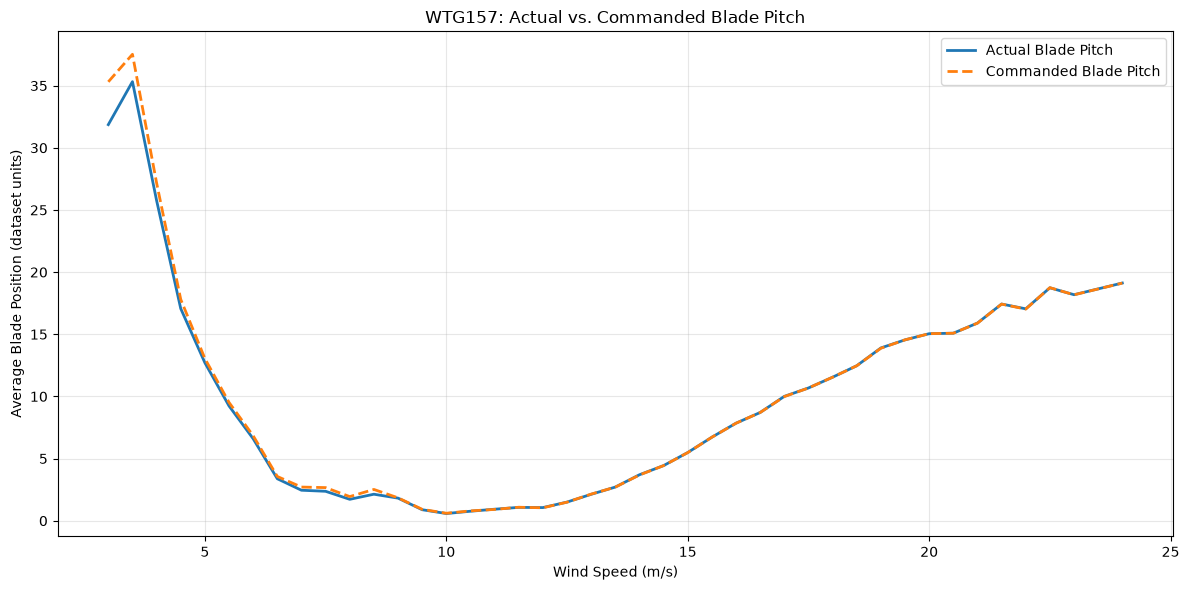

In [13]:
# ==========================================
# ACTUAL VS COMMANDED BLADE POSITION
# ==========================================

wtg157_pitch = pitch_summary[
    pitch_summary["turbine"] == "WTG157"
]

plt.figure(figsize=(12, 6))

plt.plot(
    wtg157_pitch["wind_bin"],
    wtg157_pitch["avg_pitch"],
    label="Actual Blade Pitch",
    linewidth=2
)

plt.plot(
    wtg157_pitch["wind_bin"],
    wtg157_pitch["avg_setpoint"],
    label="Commanded Blade Pitch",
    linestyle="--",
    linewidth=2
)

plt.title("WTG157: Actual vs. Commanded Blade Pitch")
plt.xlabel("Wind Speed (m/s)")
plt.ylabel("Average Blade Position (dataset units)")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()